In [1]:
# ==========================================
# 1. KONFIGURACJA ŚRODOWISKA
# ==========================================
import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Konfiguracja urządzenia (wykrywa 2x T4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Dostępne urządzenie: {device}")
print(f"Liczba GPU: {num_gpus}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Katalog wyjściowy na zapis modeli
OUTPUT_DIR = "/kaggle/working/models_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Modele będą zapisywane w: {OUTPUT_DIR}")

Dostępne urządzenie: cuda
Liczba GPU: 2
Modele będą zapisywane w: /kaggle/working/models_output


In [ ]:
# ==========================================
# 2. PRZYGOTOWANIE DANYCH
# ==========================================
from torch.utils.data import WeightedRandomSampler
import numpy as np

DATA_DIR = "/kaggle/input/skin-ds" 

# Jeśli masz 2x T4, zwiększamy batch size dla szybkości
BATCH_SIZE = 64 if num_gpus > 1 else 32
IMG_SIZE = 224

# Dodałem ColorJitter - zmiana jasności pomaga na różne oświetlenie zdjęć
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # <-- NOWOŚĆ
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Wczytywanie datasetów
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

print("Obliczanie wag dla samplera...")
try:
    # Pobieramy etykiety (targets)
    train_targets = [sample[1] for sample in image_datasets['train'].samples]
    # Liczymy wystąpienia każdej klasy
    class_counts = np.bincount(train_targets)
    # Waga to odwrotność liczebności (rzadsza klasa = większa waga)
    class_weights = 1. / class_counts
    # Przypisujemy wagę do każdego zdjęcia w zestawie treningowym
    sample_weights = [class_weights[t] for t in train_targets]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    print("Sampler utworzony pomyślnie.")
except Exception as e:
    print(f"Błąd przy tworzeniu samplera: {e}")
    sampler = None

# Definicja DataLoaderów
dataloaders = {}

if sampler:
    # Dla TRAIN używamy samplera, więc shuffle musi być False!
    dataloaders['train'] = DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, 
                                      sampler=sampler, shuffle=False, num_workers=2)
else:
    # Fallback jeśli coś pójdzie nie tak (zwykły shuffle)
    dataloaders['train'] = DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, 
                                      shuffle=True, num_workers=2)

dataloaders['val'] = DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, 
                                shuffle=False, num_workers=2)
dataloaders['test'] = DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, 
                                 shuffle=False, num_workers=2)

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"Liczba klas: {num_classes}")
print(f"Klasy: {class_names}")
print(f"Czy użyto samplera: {'TAK' if sampler else 'NIE (zwykły shuffle)'}")

Obliczanie wag dla samplera...
Sampler utworzony pomyślnie.
Liczba klas: 14
Klasy: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Chickenpox', 'Cowpox', 'Dermatofibroma', 'HFMD', 'Healthy', 'Measles', 'Melanocytic nevi', 'Melanoma', 'Monkeypox', 'Squamous cell carcinoma', 'Vascular lesions']
Czy użyto samplera: TAK


In [3]:
# ==========================================
# 3. DEFINICJE MODELI
# ==========================================

# 1. Prosty Custom CNN
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 512),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Funkcja budująca modele
def get_model(model_name, num_classes, pretrained=True):
    print(f"Initializing {model_name}...")
    
    if model_name == 'CustomCNN':
        model = CustomCNN(num_classes)
        
    elif model_name == 'ResNet50':
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'MobileNetV3':
        weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_large(weights=weights)
        num_ftrs = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'ViT':
        weights = models.ViT_B_16_Weights.DEFAULT if pretrained else None
        model = models.vit_b_16(weights=weights)
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, num_classes)

    # --- NOWY MODEL ---
    elif model_name == 'EfficientNet':
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        # EfficientNet ma inną strukturę klasyfikatora
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
    else:
        raise ValueError("Unknown model name")

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    return model.to(device)

In [4]:
# ==========================================
# 4. SILNIK TRENINGOWY
# ==========================================

def train_model(model, model_name, dataloaders, criterion, optimizer, num_epochs=10, patience=3):
    since = time.time()
    
    val_acc_history = []
    train_loss_history = []
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # Early Stopping variables
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Pasek postępu
            pbar = tqdm(dataloaders[phase], desc=f"{phase} phase", leave=False)
            
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Aktualizacja paska postępu
                pbar.set_postfix({'loss': loss.item()})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_loss_history.append(epoch_loss)
            
            # Deep Copy i Early Stopping dla walidacji
            if phase == 'val':
                val_acc_history.append(epoch_acc.item())
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    # Zapis checkpointu
                    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_best.pth")
                    torch.save(model.state_dict(), save_path)
                else:
                    epochs_no_improve += 1

        print()
        
        # Early Stopping check
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Załaduj najlepsze wagi
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_loss_history, time_elapsed

In [5]:
# ==========================================
# 5. URUCHOMIENIE PORÓWNANIA
# ==========================================

# Lista modeli
models_list = ['CustomCNN', 'MobileNetV3', 'ResNet50', 'ViT', 'EfficientNet']
results = {}

# Parametry treningu
NUM_EPOCHS = 25  
PATIENCE = 5 

criterion = nn.CrossEntropyLoss()

for model_name in models_list:
    print(f"\n{'='*40}")
    print(f"TRENING MODELU: {model_name}")
    print(f"{'='*40}")
    
    pretrained = (model_name != 'CustomCNN')
    model = get_model(model_name, num_classes, pretrained=pretrained)
    
    # EfficientNet i ViT lubią nieco mniejszy learning rate
    if model_name in ['ViT', 'EfficientNet']:
        lr = 1e-4
    else:
        lr = 1e-3
        
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    trained_model, val_acc, train_loss, duration = train_model(
        model, model_name, dataloaders, criterion, optimizer, 
        num_epochs=NUM_EPOCHS, patience=PATIENCE
    )
    
    results[model_name] = {
        'model': trained_model,
        'val_acc': val_acc,
        'train_loss': train_loss,
        'time': duration
    }
    
    del model
    torch.cuda.empty_cache()

print("\nWSZYSTKIE 5 MODELI WYTRENOWANE!")


TRENING MODELU: CustomCNN
Initializing CustomCNN...
Epoch 1/25
----------


train phase:   0%|          | 0/459 [00:00<?, ?it/s]

train Loss: 2.1288 Acc: 0.2562


val phase:   0%|          | 0/58 [00:00<?, ?it/s]

val Loss: 1.9862 Acc: 0.2776

Epoch 2/25
----------


...

val Loss: 0.4110 Acc: 0.8678

Epoch 21/25
----------


train phase:   0%|          | 0/459 [00:00<?, ?it/s]

train Loss: 0.1040 Acc: 0.9619


val phase:   0%|          | 0/58 [00:00<?, ?it/s]

val Loss: 0.4188 Acc: 0.8664

Early stopping triggered after 21 epochs!
Training complete in 77m 52s
Best val Acc: 0.8809

WSZYSTKIE 5 MODELI WYTRENOWANE!


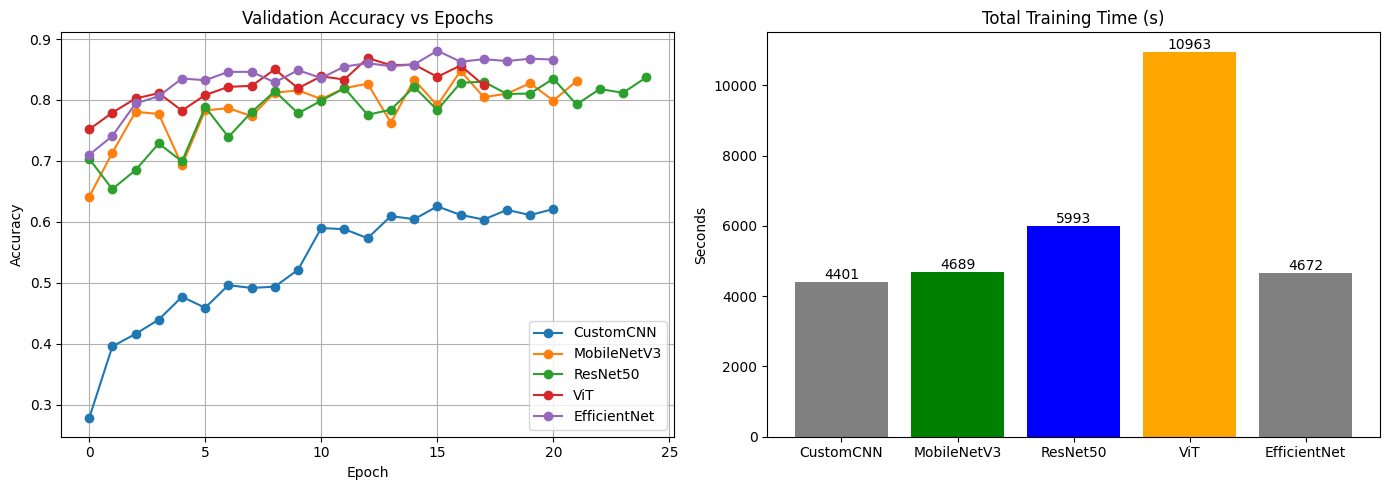

In [6]:
# ==========================================
# 6. WIZUALIZACJA WYNIKÓW
# ==========================================

plt.figure(figsize=(14, 5))

# Wykres dokładności walidacji
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(data['val_acc'], label=f"{name}", marker='o')
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Wykres czasu treningu
plt.subplot(1, 2, 2)
times = [data['time'] for name, data in results.items()]
names = list(results.keys())
bars = plt.bar(names, times, color=['gray', 'green', 'blue', 'orange'])
plt.title("Total Training Time (s)")
plt.ylabel("Seconds")
plt.bar_label(bars, fmt='%.0f')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_plots.png"))
plt.show()

Testing CustomCNN:   0%|          | 0/58 [00:00<?, ?it/s]

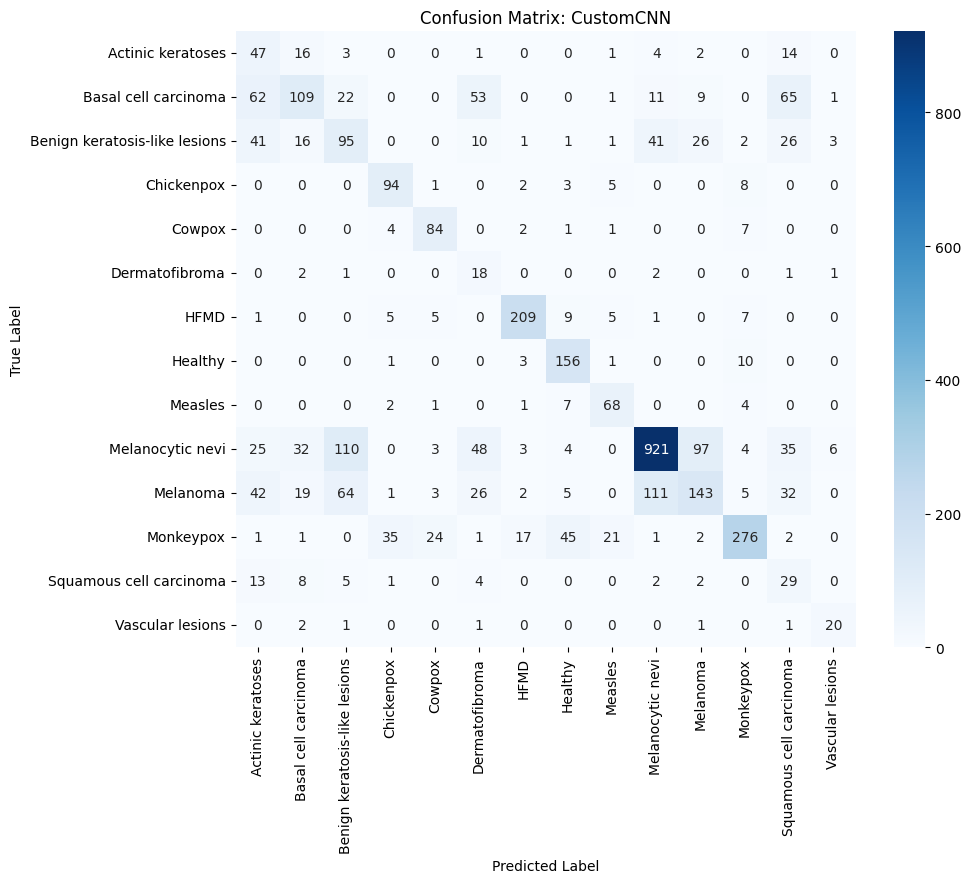


--- Classification Report: CustomCNN ---
                               precision    recall  f1-score   support

            Actinic keratoses       0.20      0.53      0.29        88
         Basal cell carcinoma       0.53      0.33      0.41       333
Benign keratosis-like lesions       0.32      0.36      0.34       263
                   Chickenpox       0.66      0.83      0.73       113
                       Cowpox       0.69      0.85      0.76        99
               Dermatofibroma       0.11      0.72      0.19        25
                         HFMD       0.87      0.86      0.87       242
                      Healthy       0.68      0.91      0.78       171
                      Measles       0.65      0.82      0.73        83
             Melanocytic nevi       0.84      0.72      0.77      1288
                     Melanoma       0.51      0.32      0.39       453
                    Monkeypox       0.85      0.65      0.74       426
      Squamous cell carcinoma     

Testing MobileNetV3:   0%|          | 0/58 [00:00<?, ?it/s]

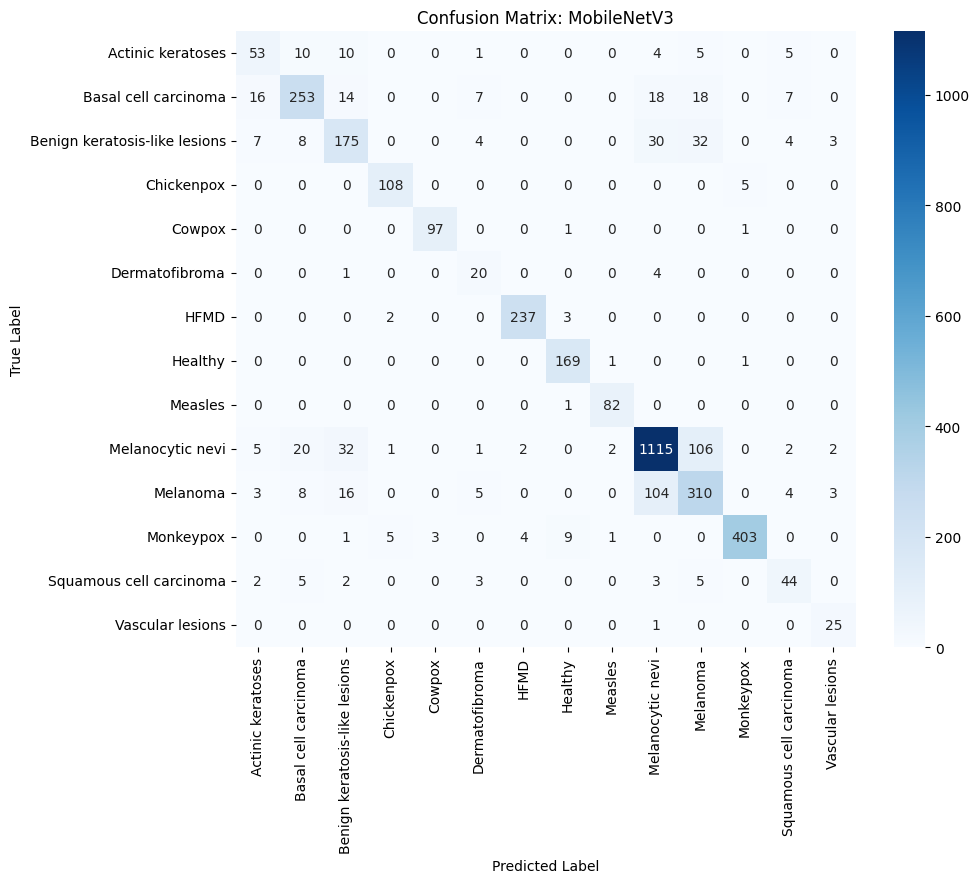


--- Classification Report: MobileNetV3 ---
                               precision    recall  f1-score   support

            Actinic keratoses       0.62      0.60      0.61        88
         Basal cell carcinoma       0.83      0.76      0.79       333
Benign keratosis-like lesions       0.70      0.67      0.68       263
                   Chickenpox       0.93      0.96      0.94       113
                       Cowpox       0.97      0.98      0.97        99
               Dermatofibroma       0.49      0.80      0.61        25
                         HFMD       0.98      0.98      0.98       242
                      Healthy       0.92      0.99      0.95       171
                      Measles       0.95      0.99      0.97        83
             Melanocytic nevi       0.87      0.87      0.87      1288
                     Melanoma       0.65      0.68      0.67       453
                    Monkeypox       0.98      0.95      0.96       426
      Squamous cell carcinoma   

Testing ResNet50:   0%|          | 0/58 [00:00<?, ?it/s]

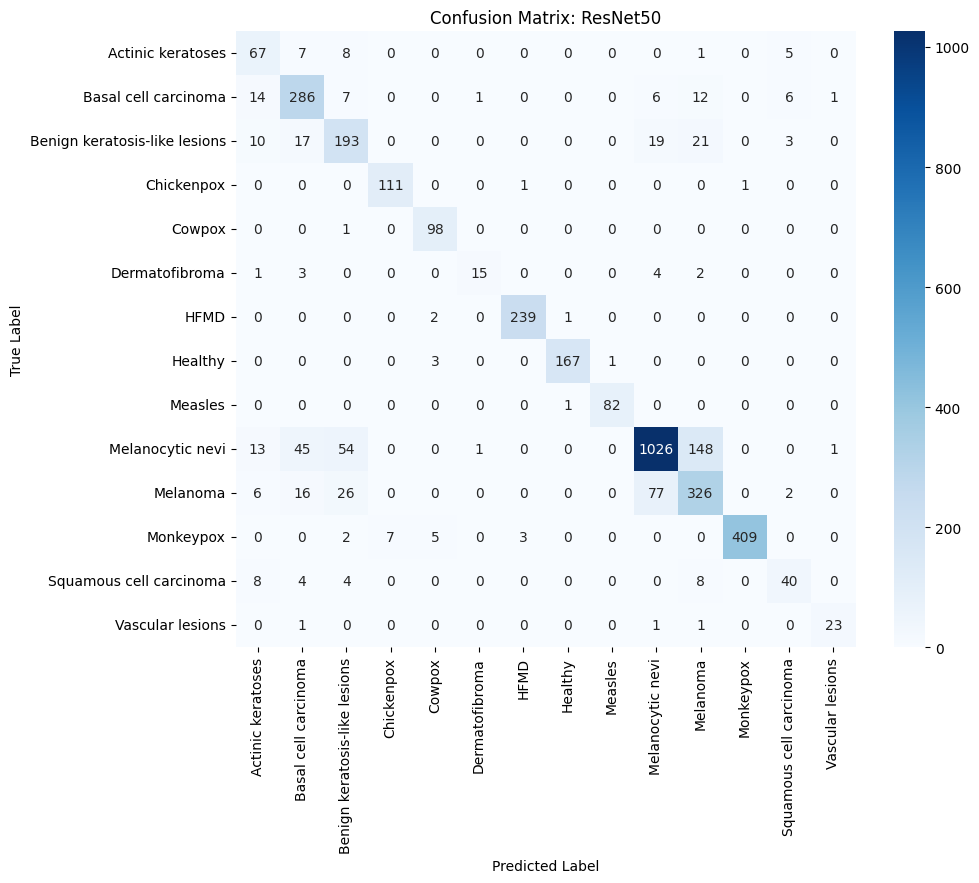


--- Classification Report: ResNet50 ---
                               precision    recall  f1-score   support

            Actinic keratoses       0.56      0.76      0.65        88
         Basal cell carcinoma       0.75      0.86      0.80       333
Benign keratosis-like lesions       0.65      0.73      0.69       263
                   Chickenpox       0.94      0.98      0.96       113
                       Cowpox       0.91      0.99      0.95        99
               Dermatofibroma       0.88      0.60      0.71        25
                         HFMD       0.98      0.99      0.99       242
                      Healthy       0.99      0.98      0.98       171
                      Measles       0.99      0.99      0.99        83
             Melanocytic nevi       0.91      0.80      0.85      1288
                     Melanoma       0.63      0.72      0.67       453
                    Monkeypox       1.00      0.96      0.98       426
      Squamous cell carcinoma      

Testing ViT:   0%|          | 0/58 [00:00<?, ?it/s]

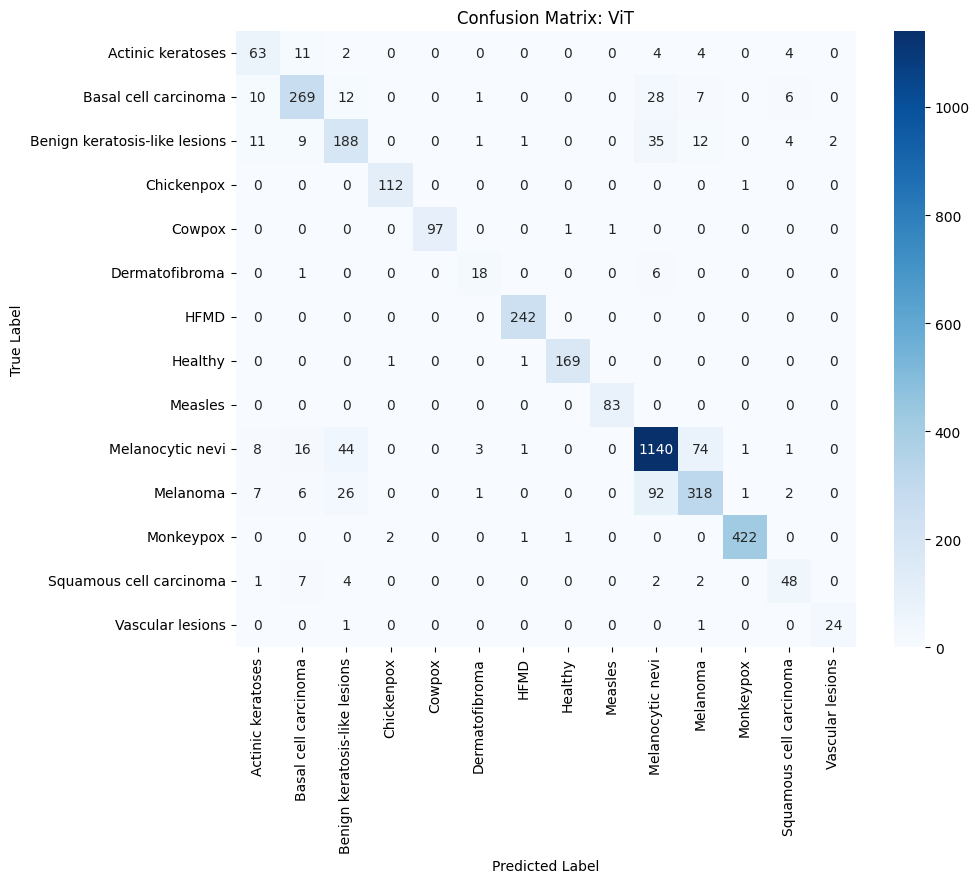


--- Classification Report: ViT ---
                               precision    recall  f1-score   support

            Actinic keratoses       0.63      0.72      0.67        88
         Basal cell carcinoma       0.84      0.81      0.83       333
Benign keratosis-like lesions       0.68      0.71      0.70       263
                   Chickenpox       0.97      0.99      0.98       113
                       Cowpox       1.00      0.98      0.99        99
               Dermatofibroma       0.75      0.72      0.73        25
                         HFMD       0.98      1.00      0.99       242
                      Healthy       0.99      0.99      0.99       171
                      Measles       0.99      1.00      0.99        83
             Melanocytic nevi       0.87      0.89      0.88      1288
                     Melanoma       0.76      0.70      0.73       453
                    Monkeypox       0.99      0.99      0.99       426
      Squamous cell carcinoma       0.74

Testing EfficientNet:   0%|          | 0/58 [00:00<?, ?it/s]

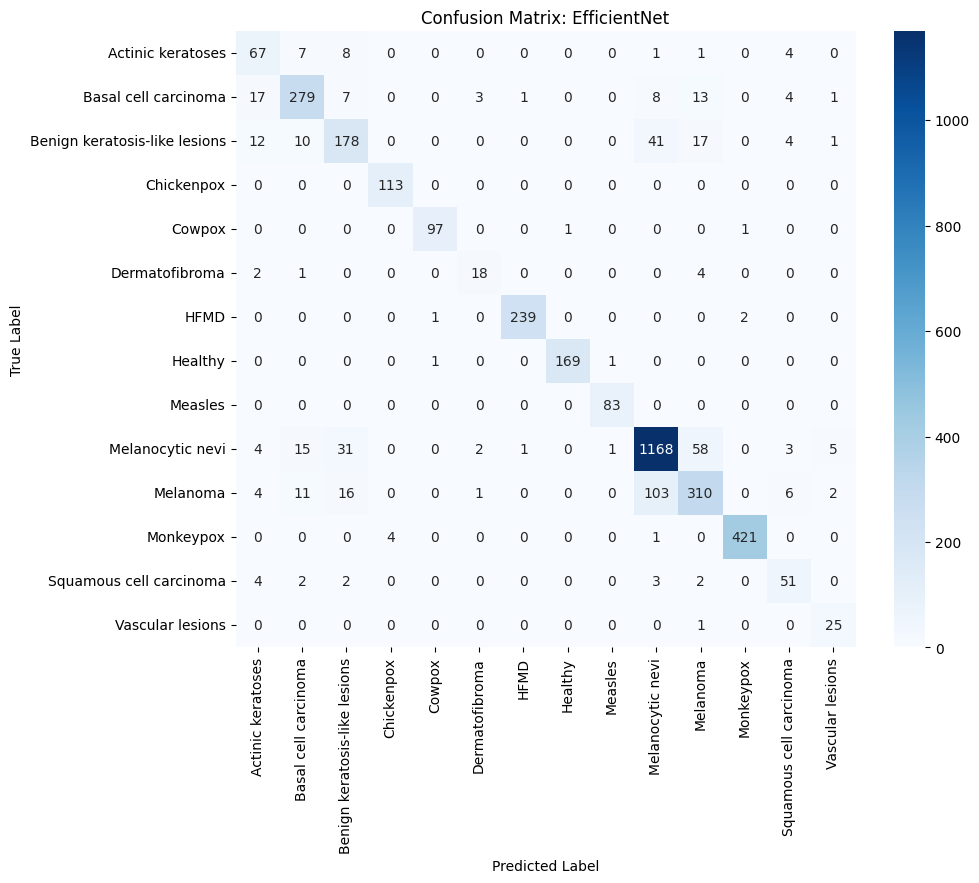


--- Classification Report: EfficientNet ---
                               precision    recall  f1-score   support

            Actinic keratoses       0.61      0.76      0.68        88
         Basal cell carcinoma       0.86      0.84      0.85       333
Benign keratosis-like lesions       0.74      0.68      0.70       263
                   Chickenpox       0.97      1.00      0.98       113
                       Cowpox       0.98      0.98      0.98        99
               Dermatofibroma       0.75      0.72      0.73        25
                         HFMD       0.99      0.99      0.99       242
                      Healthy       0.99      0.99      0.99       171
                      Measles       0.98      1.00      0.99        83
             Melanocytic nevi       0.88      0.91      0.89      1288
                     Melanoma       0.76      0.68      0.72       453
                    Monkeypox       0.99      0.99      0.99       426
      Squamous cell carcinoma  

In [7]:
# ==========================================
# 7. EWALUACJA NA ZBIORZE TESTOWYM
# ==========================================

def evaluate_on_test(model, model_name):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloaders['test'], desc=f"Testing {model_name}"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    # Macierz pomyłek
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(OUTPUT_DIR, f"cm_{model_name}.png"))
    plt.show()
    
    # Raport tekstowy
    print(f"\n--- Classification Report: {model_name} ---")
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)
    
    # Zapis raportu do pliku
    with open(os.path.join(OUTPUT_DIR, f"report_{model_name}.txt"), "w") as f:
        f.write(report)

# Uruchomienie dla każdego modelu
for name, data in results.items():
    evaluate_on_test(data['model'], name)

In [8]:
# ==========================================
# 8. TEST ODPORNOŚCI (ROBUSTNESS)
# ==========================================

def add_noise(img):
    # Dodaje szum Gaussowski
    noise = torch.randn_like(img) * 0.1
    return img + noise

def add_blur(img):
    # Dodaje rozmycie
    blur = transforms.GaussianBlur(kernel_size=5, sigma=2.0)
    return blur(img)

# Przygotujmy specjalne DataLoadery z deformacjami
robustness_transforms = {
    'noise': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.Lambda(add_noise)
    ]),
    'blur': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.Lambda(add_blur)
    ])
}

# Funkcja testująca
def test_robustness(model, transform_name, transform):
    # Tymczasowy dataset
    temp_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform)
    temp_loader = DataLoader(temp_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in temp_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
    return correct / total

print("\n--- ROBUSTNESS TEST (Acc) ---")
print(f"{'Model':<15} | {'Original':<10} | {'Noise':<10} | {'Blur':<10}")
print("-" * 55)

for name, data in results.items():
    model = data['model']
    # Oryginalny wynik (bez szumu)
    orig_acc = data['val_acc'][-1] # Bierzemy ostatni z walidacji jako przybliżenie, lub policz na test
    
    # Test z szumem
    noise_acc = test_robustness(model, 'noise', robustness_transforms['noise'])
    
    # Test z rozmyciem
    blur_acc = test_robustness(model, 'blur', robustness_transforms['blur'])
    
    print(f"{name:<15} | {orig_acc:.4f}     | {noise_acc:.4f}     | {blur_acc:.4f}")


--- ROBUSTNESS TEST (Acc) ---
Model           | Original   | Noise      | Blur      
-------------------------------------------------------
CustomCNN       | 0.6210     | 0.6100     | 0.5825
MobileNetV3     | 0.8311     | 0.7501     | 0.7646
ResNet50        | 0.8372     | 0.7950     | 0.7578
ViT             | 0.8243     | 0.8680     | 0.8416
EfficientNet    | 0.8664     | 0.7803     | 0.7474


In [9]:
# ==========================================
# 9. EXPORT MODELI
# ==========================================
import shutil
import os
import torch
# Tu jest naprawa błędu - importujemy funkcję bezpośrednio
from torch.utils.mobile_optimizer import optimize_for_mobile

print("Eksportowanie modeli pod urządzenia mobilne...")

# Tworzymy dummy input o idealnym rozmiarze
dummy_input = torch.randn(1, 3, 224, 224).to(device)

for name, data in results.items():
    model = data['model']
    
    # Obsługa DataParallel
    if isinstance(model, nn.DataParallel):
        model_to_save = model.module
    else:
        model_to_save = model
        
    model_to_save.eval()
    model_to_save.to(device)
    
    print(f"Przetwarzanie: {name}...")
    
    try:
        # KROK 1: Tracing (zamiana kodu na graf)
        if name == 'ViT':
            # ViT wymaga wyłączenia sprawdzania
            traced_model = torch.jit.trace(model_to_save, dummy_input, check_trace=False, strict=False)
        else:
            traced_model = torch.jit.trace(model_to_save, dummy_input)
            
        # KROK 2: Zapis klasycznego TorchScript (.pt)
        script_path = os.path.join(OUTPUT_DIR, f"{name}_scripted.pt")
        traced_model.save(script_path)
        print(f"    -> Zapisano standardowy TorchScript: {script_path}")

        # KROK 3: Optymalizacja dla Mobile (.ptl)
        try:
            optimized_model = optimize_for_mobile(traced_model)
            
            lite_path = os.path.join(OUTPUT_DIR, f"{name}_mobile.ptl")
            optimized_model._save_for_lite_interpreter(lite_path)
            print(f"    -> Zapisano wersję Lite (Mobile): {lite_path}")
            
        except Exception as e_mobile:
            print(f"    -> Ostrzeżenie: Nie udało się zrobić wersji Lite (.ptl), ale masz wersję .pt. Błąd: {e_mobile}")
        
    except Exception as e:
        print(f"--> BŁĄD KRYTYCZNY przy eksporcie {name}: {e}")

# Pakowanie wyników do ZIP
shutil.make_archive("/kaggle/working/results_archive", 'zip', OUTPUT_DIR)
print(f"\nGotowe! Pobierz plik 'results_archive.zip' z sekcji Output.")

Eksportowanie modeli pod urządzenia mobilne...
Przetwarzanie: CustomCNN...
    -> Zapisano standardowy TorchScript: /kaggle/working/models_output/CustomCNN_scripted.pt
    -> Zapisano wersję Lite (Mobile): /kaggle/working/models_output/CustomCNN_mobile.ptl
Przetwarzanie: MobileNetV3...
    -> Zapisano standardowy TorchScript: /kaggle/working/models_output/MobileNetV3_scripted.pt
    -> Zapisano wersję Lite (Mobile): /kaggle/working/models_output/MobileNetV3_mobile.ptl
Przetwarzanie: ResNet50...
    -> Zapisano standardowy TorchScript: /kaggle/working/models_output/ResNet50_scripted.pt
    -> Zapisano wersję Lite (Mobile): /kaggle/working/models_output/ResNet50_mobile.ptl
Przetwarzanie: ViT...


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:2174: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message


    -> Zapisano standardowy TorchScript: /kaggle/working/models_output/ViT_scripted.pt
    -> Zapisano wersję Lite (Mobile): /kaggle/working/models_output/ViT_mobile.ptl
Przetwarzanie: EfficientNet...
    -> Zapisano standardowy TorchScript: /kaggle/working/models_output/EfficientNet_scripted.pt
    -> Zapisano wersję Lite (Mobile): /kaggle/working/models_output/EfficientNet_mobile.ptl

Gotowe! Pobierz plik 'results_archive.zip' z sekcji Output.
